# Part 1: Data Exploration and Preprocessing

In this notebook, you will implement functions to load, preprocess, and visualize physiological data from the Wearable Exam Stress Dataset.

In [4]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import os

# Set style for plots
sns.set_theme(style="darkgrid")
%matplotlib inline

## 1. Data Loading

Implement the `load_data` function to read and organize the physiological data from the dataset.

In [83]:
def load_data(data_dir='data/raw'):
    import os
    import pandas as pd

    def make_df(path, name):
        with open(path, 'r') as f:
            lines = f.readlines()
            start = float(lines[0])
            step = float(lines[1])
            vals = [float(x) for x in lines[2:]]
            time = [start + i * step for i in range(len(vals))]
        return pd.DataFrame({'timestamp': time, name: vals})

    all_data = []

    subj_ids = [d for d in os.listdir(data_dir) if d.startswith('S')]

    for sid in subj_ids:
        sid_path = os.path.join(data_dir, sid)

        for sess in ['Final', 'Midterm 1', 'Midterm 2']:
            sess_path = os.path.join(sid_path, sess)
            if not os.path.isdir(sess_path):
                continue

            try:
                df_hr = make_df(os.path.join(sess_path, 'HR.csv'), 'heart_rate')
                df_eda = make_df(os.path.join(sess_path, 'EDA.csv'), 'eda')
                df_temp = make_df(os.path.join(sess_path, 'TEMP.csv'), 'temperature')

                df = df_hr.merge(df_eda, on='timestamp', how='outer')
                df = df.merge(df_temp, on='timestamp', how='outer')

                df['subject_id'] = sid
                df['session'] = sess

                all_data.append(df.sort_values('timestamp'))

            except Exception as e:
                print(f"Skip {sid} / {sess}: {e}")
                continue

    if not all_data:
        return pd.DataFrame(columns=['timestamp', 'heart_rate', 'eda', 'temperature', 'subject_id', 'session'])

    # Combine and convert timestamp to datetime
    df_all = pd.concat(all_data).reset_index(drop=True)
    df_all['timestamp'] = pd.to_datetime(df_all['timestamp'], unit='s')

    return df_all[['timestamp', 'heart_rate', 'eda', 'temperature', 'subject_id', 'session']]

In [84]:
df = load_data('Data/raw')
print(df)

                  timestamp  heart_rate       eda  temperature subject_id  \
0       2018-12-05 16:28:57         NaN  0.000000        21.89         S1   
1       2018-12-05 16:29:01         NaN  0.005125        21.89         S1   
2       2018-12-05 16:29:05         NaN  0.020501        21.89         S1   
3       2018-12-05 16:29:07       116.0       NaN          NaN         S1   
4       2018-12-05 16:29:08        82.5       NaN          NaN         S1   
...                     ...         ...       ...          ...        ...   
2105378 2018-11-12 21:32:27         NaN  0.015375          NaN         S9   
2105379 2018-11-12 21:32:31         NaN  0.014094          NaN         S9   
2105380 2018-11-12 21:32:35         NaN  0.015375          NaN         S9   
2105381 2018-11-12 21:32:39         NaN  0.014094          NaN         S9   
2105382 2018-11-12 21:32:43         NaN  0.015375          NaN         S9   

           session  
0            Final  
1            Final  
2           

## 2. Data Preprocessing

Implement the `preprocess_data` function to clean and prepare the data for analysis.

In [ ]:
def preprocess_data(data, output_dir='data/processed'):
    """Clean and prepare physiological data."""

    
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    #Dropoutliers
    def remove_outliers(df, columns, threshold=3.0):
        z = np.abs(stats.zscore(df[columns], nan_policy='omit'))
        mask = (z < threshold).all(axis=1)
        return df.loc[mask]

    #Resample
    def resample_df(df):
        df = df.set_index('timestamp')
        meta = df[['subject_id', 'session']].ffill()
        df_numeric = df.select_dtypes(include='number')
        df_resampled = df_numeric.resample('1s').mean().interpolate()
        df_resampled[['subject_id', 'session']] = meta.resample('1s').ffill()
        return df_resampled.reset_index()

    #preprocessing per subject
    processed = []
    for sid in data['subject_id'].unique():
        df_sid = data[data['subject_id'] == sid]
        df_sid.loc[:, 'timestamp'] = pd.to_datetime(df_sid['timestamp'])

        df_sid = remove_outliers(df_sid, ['heart_rate', 'eda', 'temperature'])
        df_sid = resample_df(df_sid)

        fname = f"{sid}_processed.csv"
        df_sid.to_csv(os.path.join(output_dir, fname), index=False)

        processed.append(df_sid)

    # Combine all processed subject data
    final_df = pd.concat(processed, ignore_index=True)
    print(f"Processed files saved in: {output_dir}")
    return final_df

In [95]:
processed_data = preprocess_data(df, output_dir='data/processed')

Processed files saved in: data/processed


In [96]:
processed_dir = 'data/processed'

# List all CSV files in the processed directory
files = [f for f in os.listdir(processed_dir) if f.endswith('.csv')]
print(f"Total processed files: {len(files)}\n")

# Optionally, check number of rows in each
for f in files:
    path = os.path.join(processed_dir, f)
    df = pd.read_csv(path)
    print(f"{f}: {len(df)} rows")

Total processed files: 10

S10_processed.csv: 4615070 rows
S1_processed.csv: 4615356 rows
S2_processed.csv: 4617324 rows
S3_processed.csv: 4617735 rows
S4_processed.csv: 4607868 rows
S5_processed.csv: 4607250 rows
S6_processed.csv: 4615823 rows
S7_processed.csv: 4611566 rows
S8_processed.csv: 4609844 rows
S9_processed.csv: 4606175 rows


## 3. Visualization

Implement the `plot_physiological_signals` function to create visualizations of the physiological data.

In [100]:
def plot_physiological_signals(data, subject_id, session, output_dir='plots'):
    """Plot and save physiological signals for a given subject and session."""

    # Filter data
    df = data[(data['subject_id'] == subject_id) & (data['session'] == session)].copy()
    df = df.sort_values('timestamp')
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Plot setup
    plt.figure(figsize=(15, 8))

    plt.subplot(3, 1, 1)
    plt.plot(df['timestamp'], df['heart_rate'], color='red')
    plt.ylabel('Heart Rate (bpm)')
    plt.title(f'{subject_id} - {session} - Heart Rate')
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.plot(df['timestamp'], df['eda'], color='blue')
    plt.ylabel('EDA (μS)')
    plt.title(f'{subject_id} - {session} - Electrodermal Activity')
    plt.grid(True)

    plt.subplot(3, 1, 3)
    plt.plot(df['timestamp'], df['temperature'], color='green')
    plt.ylabel('Temperature (°C)')
    plt.title(f'{subject_id} - {session} - Temperature')
    plt.xlabel('Time')
    plt.grid(True)

    plt.tight_layout()
    
    # Save and show
    plot_path = os.path.join(output_dir, f'{subject_id}_{session}_signals.png')
    plt.savefig(plot_path)
    print(f"Plot saved to {plot_path}")
    
    plt.show()


Plot saved to plots\S1_Final_signals.png


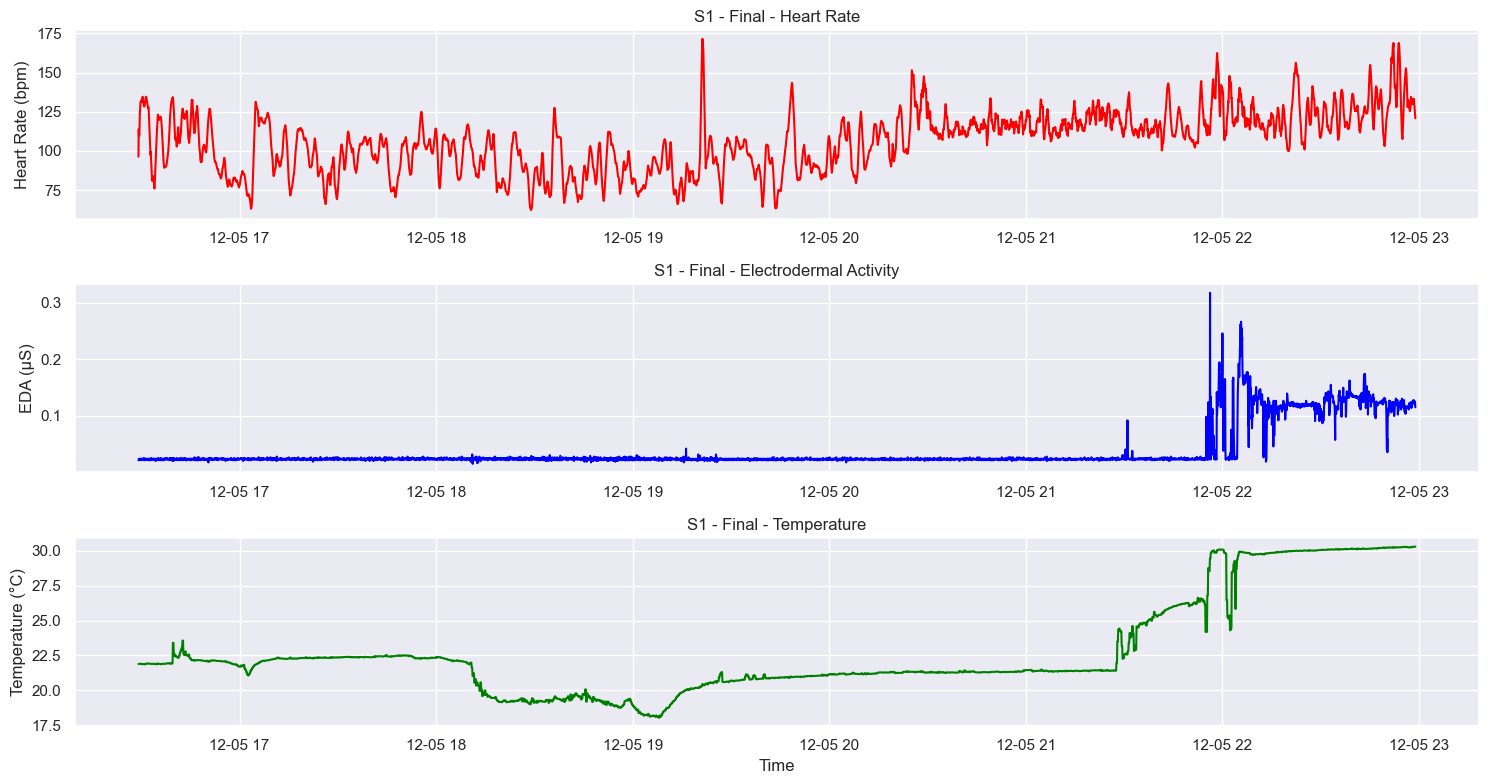

In [101]:
plot_physiological_signals(processed_data, subject_id='S1', session='Final')